In [1]:
# ==============================================================================
# 0. PRE-REQUISITES (Installs SHAP and TensorFlow automatically)
# ==============================================================================
!pip install shap tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import shap

# Deep Learning Core components for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set plotting style
sns.set_theme(style="whitegrid")


In [2]:
# ==============================================================================
# PHASE 1: Advanced Data Preprocessing & Feature Engineering
# ==============================================================================
print("--- PHASE 1: Data Preprocessing & Feature Engineering ---")

df = pd.read_csv('Educational_Gap_Punjab.csv')

# Handle missing values using regional medians
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Year', errors='ignore')
for col in num_cols:
    df[col] = df.groupby('Region')[col].transform(lambda x: x.fillna(x.median()))

# Feature Engineering
df['Gender_Parity_Index_Enrollment'] = df['Girls_Enrollment_Rate'] / df['Boys_Enrollment_Rate']
df['Urban_Rural_Disparity_Enrollment'] = df['Urban_Enrollment_Rate'] - df['Rural_Enrollment_Rate']

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print("Data preprocessing complete.\n")


--- PHASE 1: Data Preprocessing & Feature Engineering ---
Data preprocessing complete.



--- PHASE 2: EDA & Statistical Rigor ---
Descriptive Statistics:
                       Overall_Enrollment_Rate  Overall_Literacy_Rate
Region                                                              
North/Central Punjab                83.303747              82.738244
South Punjab                        69.095327              63.676729 



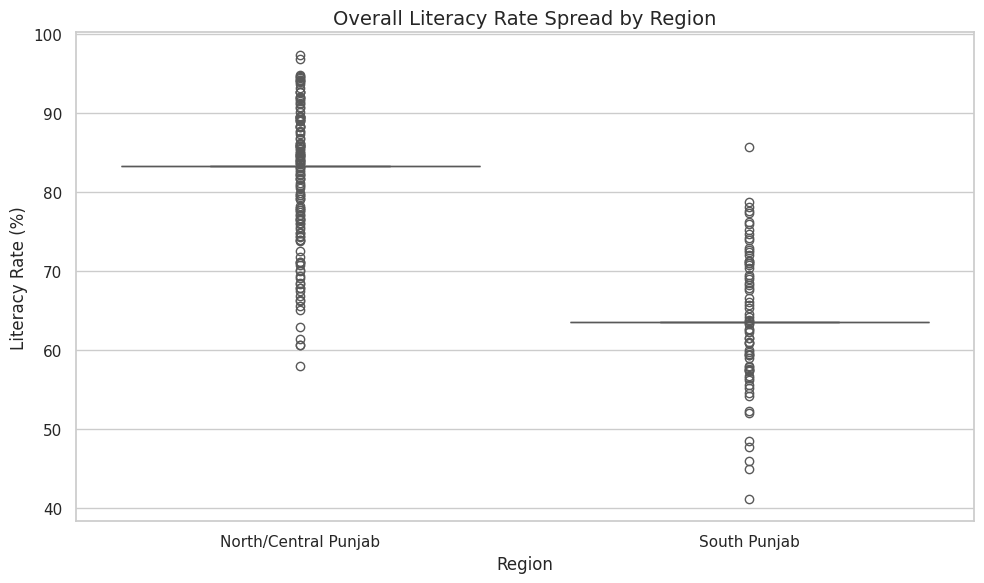

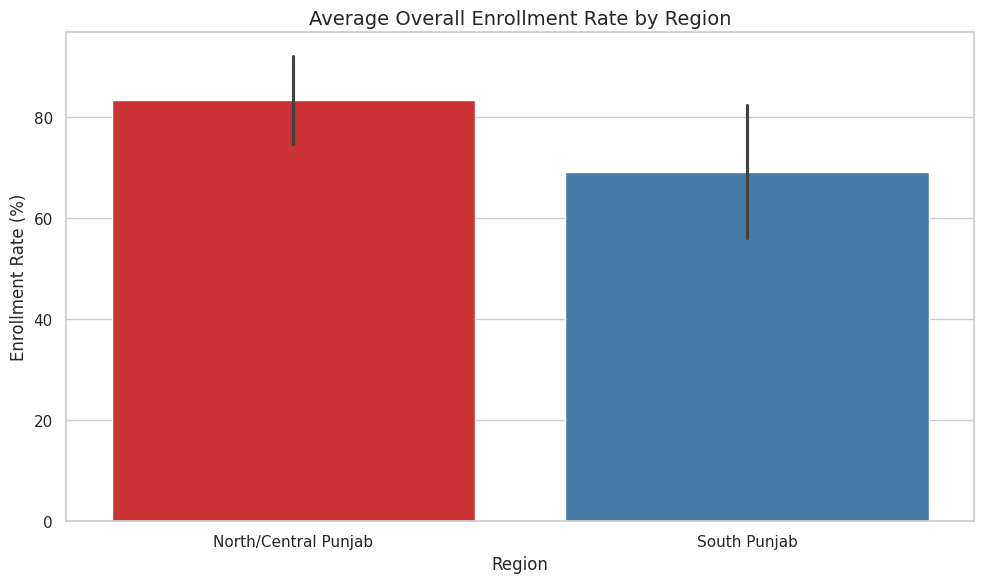

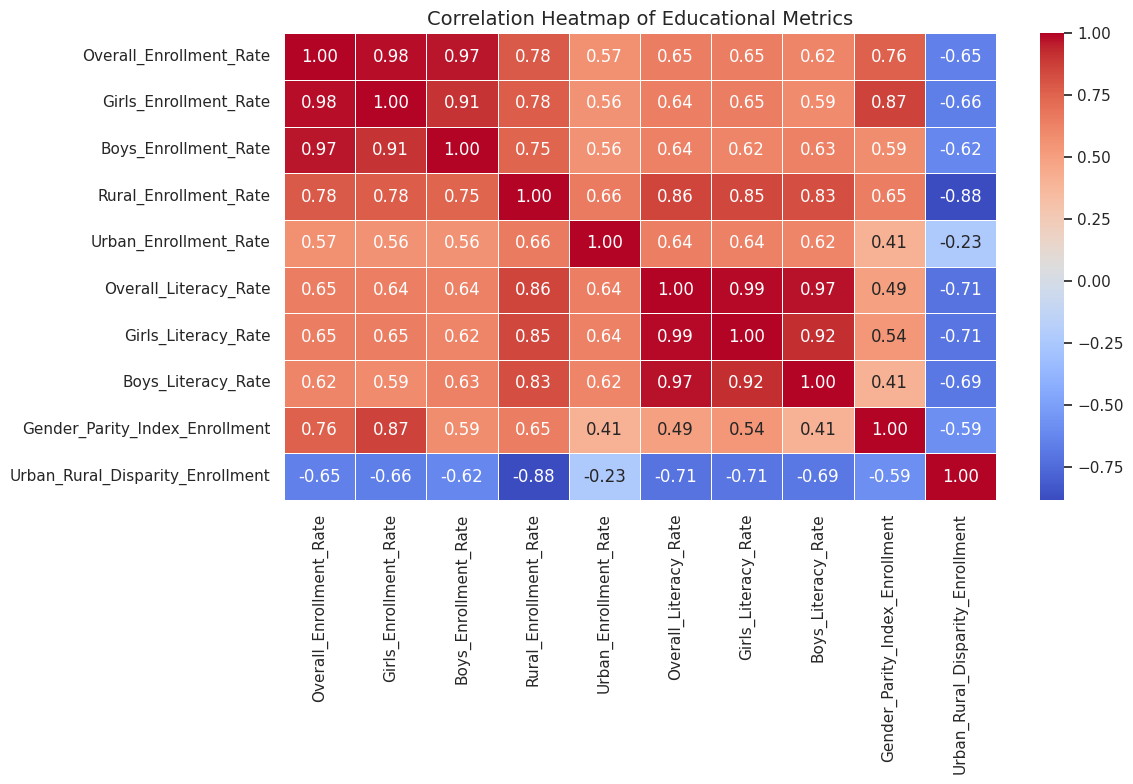

Independent T-Test on Overall Literacy Rate:
T-Statistic: -44.2518
P-Value: 5.4262e-161
Conclusion: Reject H0. There is a statistically significant educational gap.



In [3]:
# ==============================================================================
# PHASE 2: Exploratory Data Analysis (EDA) & Statistical Rigor
# ==============================================================================
print("--- PHASE 2: EDA & Statistical Rigor ---")

# 1. Descriptive Statistics
desc_stats = df.groupby('Region')[['Overall_Enrollment_Rate', 'Overall_Literacy_Rate']].mean()
print("Descriptive Statistics:\n", desc_stats, "\n")

# 2. RESTORED: Boxplot for Literacy Spread
plt.figure(figsize=(10, 6))
ax1 = sns.boxplot(x='Region', y='Overall_Literacy_Rate', hue='Region', data=df, palette='Set2')
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
plt.title('Overall Literacy Rate Spread by Region', fontsize=14)
plt.ylabel('Literacy Rate (%)')
plt.tight_layout()
plt.show()

# 3. RESTORED: Barplot for Enrollment
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x='Region', y='Overall_Enrollment_Rate', hue='Region', data=df, palette='Set1', errorbar='sd')
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
plt.title('Average Overall Enrollment Rate by Region', fontsize=14)
plt.ylabel('Enrollment Rate (%)')
plt.tight_layout()
plt.show()

# 4. RESTORED: Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_features = num_cols.tolist() + ['Gender_Parity_Index_Enrollment', 'Urban_Rural_Disparity_Enrollment']
sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Educational Metrics', fontsize=14)
plt.tight_layout()
plt.show()

# 5. Statistical Hypothesis Testing
south_lit = df[df['Region'] == 'South Punjab']['Overall_Literacy_Rate']
north_lit = df[df['Region'] == 'North/Central Punjab']['Overall_Literacy_Rate']
t_stat, p_val = stats.ttest_ind(south_lit, north_lit, equal_var=False)
print(f"Independent T-Test on Overall Literacy Rate:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}")
if p_val < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant educational gap.\n")
else:
    print("Conclusion: Fail to reject H0. No significant educational gap detected.\n")

In [4]:


# ==============================================================================
# PHASE 3: Multi-Model Architecture & Group Optimization
# ==============================================================================
print("--- PHASE 3: Group-Based Split & Multi-Model Implementation ---")

df['Target'] = df['Region'].apply(lambda x: 1 if x == 'South Punjab' else 0)

model_features = [
    'Girls_Enrollment_Rate', 'Boys_Enrollment_Rate',
    'Rural_Enrollment_Rate', 'Urban_Enrollment_Rate',
    'Gender_Parity_Index_Enrollment', 'Urban_Rural_Disparity_Enrollment'
]

X = df[model_features]
y = df['Target']
groups = df['District']

# GroupShuffleSplit to keep entire districts separated
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# Feature Scaling (Essential for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODEL 1 TREATMENT: Reshape and Train LSTM Network ---
print("Preparing 3D tensor shapes for LSTM architecture...")
X_train_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print("Training Baseline Model: Long Short-Term Memory (LSTM) Network...")
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(32, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lstm_model.fit(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
print("LSTM Training complete.\n")


# --- MODEL 2 TREATMENT: Regularized Random Forest ---
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 4],
    'min_samples_leaf': [5, 8],
    'min_samples_split': [10]
}

print("Training Ensemble Model: Optimizing Random Forest via Grouped CV...")
grid_search = GridSearchCV(rf, param_grid, cv=GroupShuffleSplit(n_splits=5, random_state=42), n_jobs=-1)
grid_search.fit(X_train, y_train, groups=groups_train)
best_rf = grid_search.best_estimator_

print("Optimized Random Forest Hyperparameters:", grid_search.best_params_, "\n")

--- PHASE 3: Group-Based Split & Multi-Model Implementation ---
Preparing 3D tensor shapes for LSTM architecture...
Training Baseline Model: Long Short-Term Memory (LSTM) Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Training complete.

Training Ensemble Model: Optimizing Random Forest via Grouped CV...
Optimized Random Forest Hyperparameters: {'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 100} 



--- PHASE 4: Advanced Evaluation & Explainability ---
=== MODEL COMPARISON SUMMARY ===
LSTM Network AUC Score: 0.9467
Random Forest Classifier AUC Score: 0.9489

--- LSTM Network Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       108
           1       0.73      0.89      0.80        54

    accuracy                           0.85       162
   macro avg       0.83      0.86      0.84       162
weighted avg       0.87      0.85      0.85       162

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       108
           1       0.78      0.83      0.80        54

    accuracy                           0.86       162
   macro avg       0.84      0.86      0.85       162
weighted avg       0.87      0.86      0.87       162



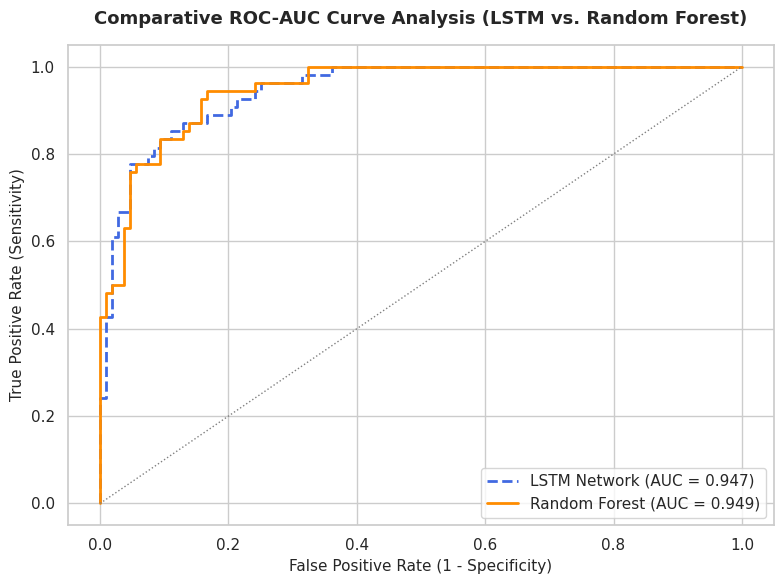

In [5]:
# ==============================================================================
# PHASE 4: Advanced Evaluation & Explainability
# ==============================================================================
print("--- PHASE 4: Advanced Evaluation & Explainability ---")

# Generate Predictions and Probabilities
y_prob_lstm = lstm_model.predict(X_test_lstm, verbose=0).ravel()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)

# Scores
auc_lstm = roc_auc_score(y_test, y_prob_lstm)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"=== MODEL COMPARISON SUMMARY ===")
print(f"LSTM Network AUC Score: {auc_lstm:.4f}")
print(f"Random Forest Classifier AUC Score: {auc_rf:.4f}\n")

print("--- LSTM Network Classification Report ---")
print(classification_report(y_test, y_pred_lstm))

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# Plotting BOTH ROC Curves on a Single Graph
plt.figure(figsize=(8, 6))
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM Network (AUC = {auc_lstm:.3f})', color='royalblue', linestyle='--', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle=':')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Comparative ROC-AUC Curve Analysis (LSTM vs. Random Forest)', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



Generating clean SHAP plot for the top-performing Random Forest model...


<Figure size 640x480 with 0 Axes>

<Figure size 1100x600 with 0 Axes>

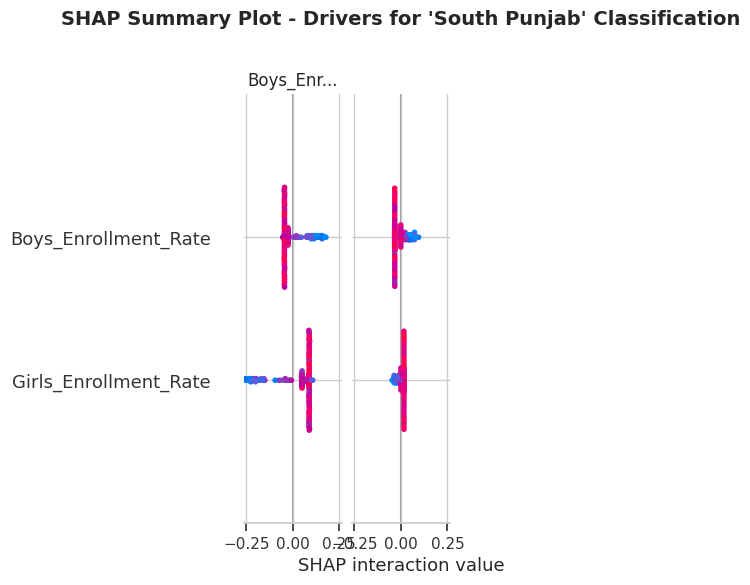

In [6]:
# ==============================================================================
# FINAL SHAP SUMMARY PLOT BLOCK
# ==============================================================================
print("\nGenerating clean SHAP plot for the top-performing Random Forest model...")
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list) and len(shap_values) > 1:
    plot_values = shap_values[1]
else:
    plot_values = shap_values

plt.clf()
plt.figure(figsize=(11, 6))
shap.summary_plot(plot_values, X_test, feature_names=X_test.columns, show=False)
ax_shap = plt.gca()
ax_shap.set_title("SHAP Summary Plot - Drivers for 'South Punjab' Classification", fontsize=14, fontweight='bold', pad=50)
plt.subplots_adjust(top=0.80, left=0.35, bottom=0.15)
plt.show()